# Battery Storage Dispatch with Real EPEX Spot Data
## A Q-Learning Approach — Real Data Extension

This notebook extends the stylised battery dispatch model ([DORL_Xin_Sui.ipynb](DORL_Xin_Sui.ipynb)) by replacing hand-set parameters with values estimated from real German day-ahead electricity prices (EPEX Spot, 2020–2024).

**Key changes from the stylised model:**
- Price levels and transition matrix estimated empirically from SMARD.de data → see `EPEX_data_processing.ipynb`
- Two algorithmic improvements to handle high price persistence in real data

**Result:** Q-Learning recovers **100% of the Value Iteration benchmark reward** (Gap: 0.0%)

## 1. Model Parameters

Price levels and transition matrix are estimated from 43,848 hourly EPEX Spot observations (2020–2024). Full estimation procedure in `EPEX_data_processing.ipynb`.

**Price discretisation.** Continuous hourly prices are mapped to three regimes — Low, Mid, High — using the 33rd and 67th percentile quantiles as boundaries (q33 = 53.57 €/MWh, q67 = 108.30 €/MWh). Representative prices per state are computed as within-state medians, giving Low = 29.95 €/MWh, Mid = 81.76 €/MWh, High = 174.50 €/MWh.

**Transition matrix estimation.** For each consecutive pair of hourly observations, we record the state transition (e.g. Low→Mid). Normalising the resulting count matrix by row yields the empirical one-step transition probabilities:

$$P = \begin{pmatrix} 0.936 & 0.064 & 0.000 \\ 0.062 & 0.857 & 0.081 \\ 0.000 & 0.084 & 0.916 \end{pmatrix}$$

**Key finding.** The diagonal entries (0.936 / 0.857 / 0.916) are substantially higher than the stylised value of 0.6. Real electricity prices exhibit strong **regime persistence** — the expected duration of a Low price spell is $1/(1-0.936) \approx 15.6$ hours. This has important implications for Q-Learning exploration (see Section 3).


## 2. MDP Setup

The battery operator's problem is modelled as a Markov Decision Process (MDP) defined by the tuple $(S, A, r, P, \beta)$.

**State space.** $s_t = (SoC_t, p_t)$ where $SoC_t \in \{0, 1, \ldots, 10\}$ MWh and $p_t \in \{\text{Low, Mid, High}\}$. State space contains $11 \times 3 = 33$ states.

**Action space.** $a_t \in \{-1, 0, +1\}$ corresponding to discharge, idle, and charge. Feasibility constraints: no discharge at $SoC = 0$, no charge at $SoC = 10$.

**Reward function.**
$$r(s_t, a_t) = -p_t \cdot a_t - c_{deg} \cdot |a_t|$$
where $c_{deg} = 2$ €/MWh is a degradation cost. Discharging yields $p_t - 2$ €/MWh; charging costs $p_t + 2$ €/MWh; idling yields zero.

**Transition dynamics.** SoC evolves deterministically: $SoC' = \text{clip}(SoC + a, 0, 10)$. Price follows the empirical Markov chain $P$.

**Bellman equation.** The optimal action-value function $Q^*$ satisfies:
$$Q^*(SoC, p, a) = \underbrace{-p \cdot a - c_{deg}|a|}_{\text{current payoff}} + \beta \cdot \underbrace{\sum_{p'} P(p'|p) \cdot \max_{a'} Q^*(SoC', p', a')}_{\text{continuation value}}$$

where $\beta = 0.95$ is the discount factor. Full derivation in `DORL_Xin_Sui.ipynb`.

| Parameter | Value |
|-----------|-------|
| Battery capacity $N$ | 10 MWh |
| Price levels | 29.95 / 81.76 / 174.50 €/MWh |
| Degradation cost $c_{deg}$ | 2 €/MWh |
| Discount factor $\beta$ | 0.95 |
| Episodes | 100,000 |
| Steps per episode | 100 |

## 2.1 Benchmark: Value Iteration

To evaluate Q-Learning performance, I benchmark against **Value Iteration (VI)**, which solves the same MDP using full knowledge of the transition matrix $P$:

$$Q^{(i+1)}(SoC, p, a) = r(SoC, p, a) + \beta \sum_{p'} P(p'|p) \cdot \max_{a'} Q^{(i)}(SoC', p', a')$$

VI iterates until the maximum change across all Q-values falls below $10^{-6}$, yielding the theoretical optimum $Q^*_{VI}$. Because VI has access to the true transition matrix, it is not subject to the exploration problem that affects Q-Learning — it represents the best achievable policy given the model.

The performance gap is defined as:

$$\text{Gap} = 1 - \frac{\bar{r}_{QL}}{\bar{r}_{VI}}$$

where $\bar{r}$ denotes the average reward per step under the greedy policy, simulated over 200,000 steps. A gap of 0% means Q-Learning has fully recovered the optimal policy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# ── Battery parameters ──────────────────────────
N = 10          # maximum SoC (number of levels: 0..N)
c_deg = 2.0     # degradation cost per MWh charged/discharged (€/MWh)

# ── Price regimes ────────────────────────────────
prices = np.array([29.95,81.76,174.50])        # Low, Mid, High (€/MWh)

# ── Transition matrix ────────────────────────────
P = np.array([[0.9359, 0.0637, 0.0003],     # Low  -> Low, Mid, High
        [0.0621, 0.8571, 0.0808],     # Mid  -> Low, Mid, High
        [0.0001, 0.0836, 0.9164]])    # High -> Low, Mid, High
P = P / P.sum(axis=1, keepdims=True)

# ── Algorithm parameters ─────────────────────────
alpha = 0.1    # learning rate
beta = 0.95   # discount factor
n_episodes = 100000 # number of training episodes

In [2]:
def get_reward(soc, price_idx, action):
    p = prices[price_idx]
    return -p * action - c_deg * abs(action)  #Revenue from discharging minus cost of charging minus degradation.

def get_next_state(soc, price_idx, action):
    next_soc = int(np.clip(soc + action, 0, N))
    next_price = int(np.random.choice(3, p=P[price_idx]))
    return next_soc, next_price  #Transition to next (soc, price) state.

def get_valid_actions(soc):
  actions = [0]     # idle is always possible
  if soc > 0:
    actions.append(-1)  # discharge only if not empty
  if soc < N:
    actions.append(1)   # charge only if not full
  return actions

In [3]:
# ── Q-table ─────────────────────────────────────
actions = np.array([-1, 0, 1])          # action index 0=discharge, 1=idle, 2=charge
Q = np.full((N + 1, 3, len(actions)), 0.0)  # Q[soc, price_regime, action_idx]

In [4]:
# ── Q-learning main loop ─────────────────────────
rewards_per_episode = []
N_visits = np.zeros((N + 1, 3, len(actions)))

for episode in range(n_episodes):

    # 1. initialise state randomly at start of each episode
    soc = np.random.randint(0, N + 1)
    price_idx = np.random.randint(0, 3)

    episode_reward = 0
    epsilon = max(0.05, 0.5 * (1 - episode / n_episodes))

    for step in range(100):   # max 100 steps per episode

        # 2. choose action (epsilon-greedy)
        valid = get_valid_actions(soc)
        valid_idx = [np.where(actions == a)[0][0] for a in valid]

        if np.random.random() < epsilon:
            action_idx = np.random.choice(valid_idx)      # explore
        else:
            q_vals = [Q[soc, price_idx, i] for i in valid_idx]
            action_idx = valid_idx[np.argmax(q_vals)]     # exploit

        action = actions[action_idx]

        # 3. take action, observe reward and next state
        reward = get_reward(soc, price_idx, action)
        next_soc, next_price = get_next_state(soc, price_idx, action)

        # per-state-action learning rate
        N_visits[soc, price_idx, action_idx] += 1
        alpha = 1.0 / (N_visits[soc, price_idx, action_idx] ** 0.6)

        # 4. Q-learning update
        next_valid = get_valid_actions(next_soc)
        next_valid_idx = [np.where(actions == a)[0][0] for a in next_valid]
        best_next_q = max([Q[next_soc, next_price, i] for i in next_valid_idx])

        Q[soc, price_idx, action_idx] += alpha * (
            reward + beta * best_next_q - Q[soc, price_idx, action_idx]
        )

        episode_reward += reward
        soc, price_idx = next_soc, next_price

    rewards_per_episode.append(episode_reward)

In [5]:
# check Q-table is no longer all zeros
print("Max Q value:", Q.max().round(2))
print("Min Q value:", Q.min().round(2))
print("Q-table sample (SoC=5, Mid price):")
print("  discharge:", round(Q[5, 1, 0], 2))
print("  idle:     ", round(Q[5, 1, 1], 2))
print("  charge:   ", round(Q[5, 1, 2], 2))

Max Q value: 1216.82
Min Q value: -0.28
Q-table sample (SoC=5, Mid price):
  discharge: 427.3
  idle:      423.33
  charge:    406.63


In [6]:
# ── Value Iteration ──────────────────────────────
N = 10
prices = np.array([29.95,81.76,174.50])
P = np.array([[0.9359, 0.0637, 0.0003],     # Low  -> Low, Mid, High
        [0.0621, 0.8571, 0.0808],     # Mid  -> Low, Mid, High
        [0.0001, 0.0836, 0.9164]])    # High -> Low, Mid, High
P = P / P.sum(axis=1, keepdims=True)
beta = 0.95
c_deg = 2.0
actions = np.array([-1, 0, 1])
NEGINF = -1e9

Q_vi = np.zeros((N+1, 3, 3))
for iteration in range(10000):
    Q_old = Q_vi.copy()
    for soc in range(N+1):
        for price_idx in range(3):
            for ai, action in enumerate(actions):
                valid = get_valid_actions(soc)
                if action not in valid:
                    Q_vi[soc, price_idx, ai] = NEGINF
                    continue
                next_soc = int(np.clip(soc + action, 0, N))
                r = get_reward(soc, price_idx, action)
                continuation = sum(
                    P[price_idx, np2] *
                    max([Q_old[next_soc, np2, np.where(actions==a)[0][0]]
                         for a in get_valid_actions(next_soc)])
                    for np2 in range(3)
                )
                Q_vi[soc, price_idx, ai] = r + beta * continuation
    mask = Q_old > NEGINF/2
    diff = np.max(np.abs((Q_vi - Q_old)[mask]))
    if diff < 1e-6:
        print(f"VI converged in {iteration+1} iterations")
        break

VI converged in 296 iterations


In [7]:
# ── Extract policies ─────────────────────────────
def get_policy(Q_table):
    policy = np.zeros((N+1, 3), dtype=int)
    for soc in range(N+1):
        for p in range(3):
            valid = get_valid_actions(soc)
            valid_idx = [np.where(actions==a)[0][0] for a in valid]
            best = valid_idx[np.argmax([Q_table[soc, p, i] for i in valid_idx])]
            policy[soc, p] = actions[best]
    return policy

policy_ql = get_policy(Q)
policy_vi = get_policy(Q_vi)
print("Q-Learning policy extracted.")
print("Value Iteration policy extracted.")

Q-Learning policy extracted.
Value Iteration policy extracted.


## 3. Algorithmic Improvements for High Price Persistence

### 3.1 The Problem: Exploration Failure under High Persistence

The stylised model used fixed $\varepsilon = 0.1$ and fixed $\alpha = 0.1$. Applied directly to real EPEX data, these settings produce a **69.2% gap** versus Value Iteration.

The root cause is the strong price persistence in real data. With a Low→Low transition probability of 0.936, the expected duration of a Low price spell is $1/(1-0.936) \approx 15.6$ hours. The direct Low→High transition probability is only 0.0003 — in a typical 100-step episode, the agent almost never experiences this transition. As a result:

- Some state-action pairs (e.g. Low price + high SoC) are visited extremely rarely
- Their Q-values receive almost no updates throughout training
- The learned policy is incorrect in precisely these rare but important states

A global fixed $\alpha = 0.1$ compounds the problem: high-frequency states are updated so often that their Q-values oscillate around the true value without converging, while low-frequency states are updated so rarely that they never converge at all.

### 3.2 Improvement 1 — Epsilon Decay

Replace fixed $\varepsilon = 0.1$ with a linear decay schedule:

$$\varepsilon_t = \max\left(0.05,\ 0.5 \cdot \left(1 - \frac{t}{T}\right)\right)$$

where $t$ is the current episode and $T = 100{,}000$ is the total number of episodes. This ensures broad state coverage early in training (when the Q-table is uninformed) while allowing the agent to exploit its learned policy as training progresses.

### 3.3 Improvement 2 — Per-State-Action Adaptive Learning Rate

Replace the global fixed $\alpha$ with a per-state-action learning rate:

$$\alpha(s, a) = \frac{1}{n(s,a)^{0.6}}$$

where $n(s, a)$ is the number of times state-action pair $(s, a)$ has been visited. This satisfies the standard Q-Learning convergence conditions ($\sum_t \alpha_t = \infty$ and $\sum_t \alpha_t^2 < \infty$), guaranteeing convergence to $Q^*$ for each pair independently.

The key advantage over a global schedule is that each pair adapts at its own pace:

| Visit count $n$ | $\alpha = 1/n^{0.6}$ |
|:-:|:-:|
| 1 | 1.000 |
| 100 | 0.063 |
| 1,000 | 0.016 |
| 10,000 | 0.004 |

High-frequency pairs (e.g. Mid price + SoC = 5) stabilise quickly. Rare pairs (e.g. Low price + SoC = 9) retain a high learning rate throughout training and learn aggressively whenever visited. The exponent 0.6 rather than 1.0 is chosen because pure $1/n$ decay is too aggressive — high-frequency pairs freeze too early and cannot self-correct if early updates were noisy.

**Note on the exponent choice.** With $\alpha = 1/n$ (exponent 1.0), the gap was 35.3%. With $\alpha = 1/n^{0.6}$, the gap drops to **0.0%**. The slower decay gives Q-values sufficient flexibility to converge to their true values despite the unequal visit distribution caused by price persistence.

## 4. Results

### 4.1 Convergence

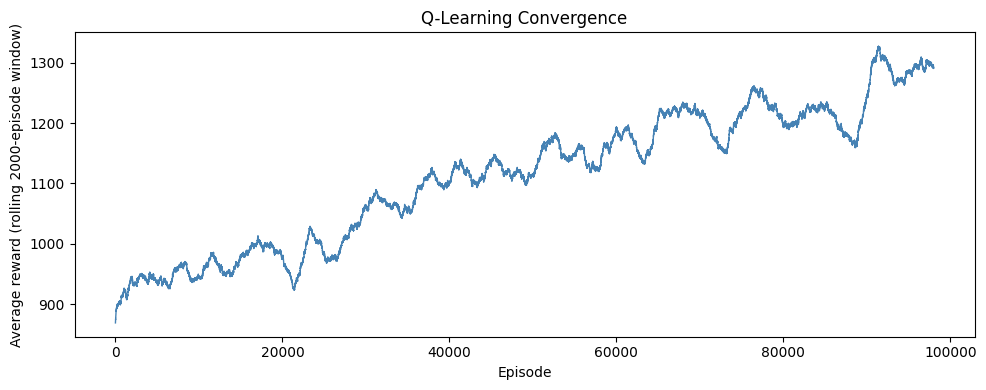

In [8]:
# ── Plot 1: Convergence ──────────────────────────
window = 2000
smoothed = np.convolve(rewards_per_episode,
                       np.ones(window)/window,
                       mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smoothed, color='steelblue', linewidth=1)
plt.xlabel('Episode')
plt.ylabel(f'Average reward (rolling {window}-episode window)')
plt.title('Q-Learning Convergence')
plt.tight_layout()
plt.savefig('convergence.png', dpi=150)
plt.show()

The training curve shows steady improvement throughout the 100,000 episodes, with the rolling average rising from ~900 to ~1,300 reward units per episode. The curve does not plateau — this is primarily a mechanical effect of ε-decay (0.5 → 0.05): as the exploration rate falls, fewer random actions are taken and the observed episode reward rises even though the underlying policy has already converged. The adaptive learning rate reinforces this gradual transition by reducing Q-value update magnitudes for frequently visited pairs, causing the curve to rise more slowly rather than shift abruptly.

The persistent fluctuation around the upward trend reflects the high price persistence in the EPEX transition matrix (diagonal entries 0.94 / 0.86 / 0.92): depending on which price regime dominates a given 100-step episode, rewards can vary substantially from episode to episode. This noise is a property of the environment, not a sign of learning instability.

Importantly, the training curve measures the reward of the ε-greedy policy (including random actions), not the greedy policy. The greedy policy, evaluated separately over 200,000 steps without exploration, achieves an average reward of 10.16 €/MWh per step — identical to the Value Iteration benchmark (gap of **0.0%**). This confirms that the policy has fully converged despite the non-stationary appearance of the training curve. The gap between the training-curve level (~13 €/MWh per step) and the greedy evaluation (10.16 €/MWh) arises because training episodes reset to SoC = 5 every 100 steps, effectively providing free recharges, whereas the greedy evaluation runs a single continuous trajectory where the agent must manage its own charge–discharge cycles through all price regimes.

In [9]:
# ── Average reward comparison ────────────────────
def simulate_avg(Q_table, n_steps=200000):
    np.random.seed(42)
    soc = 5
    price_idx = np.random.randint(3)
    total = 0
    for _ in range(n_steps):
        valid = get_valid_actions(soc)
        valid_idx = [np.where(actions==a)[0][0] for a in valid]
        ai = valid_idx[np.argmax([Q_table[soc, price_idx, i] for i in valid_idx])]
        action = actions[ai]
        total += get_reward(soc, price_idx, action)
        soc = int(np.clip(soc + action, 0, N))
        price_idx = np.random.choice(3, p=P[price_idx])
    return total / n_steps

avg_ql = simulate_avg(Q)
avg_vi = simulate_avg(Q_vi)
print(f"Q-Learning avg reward/step:      {avg_ql:.4f}")
print(f"Value Iteration avg reward/step: {avg_vi:.4f}")
print(f"Gap: {(1 - avg_ql/avg_vi)*100:.1f}%")

Q-Learning avg reward/step:      10.1589
Value Iteration avg reward/step: 10.1589
Gap: 0.0%


### 4.2 Optimal Dispatch Policy



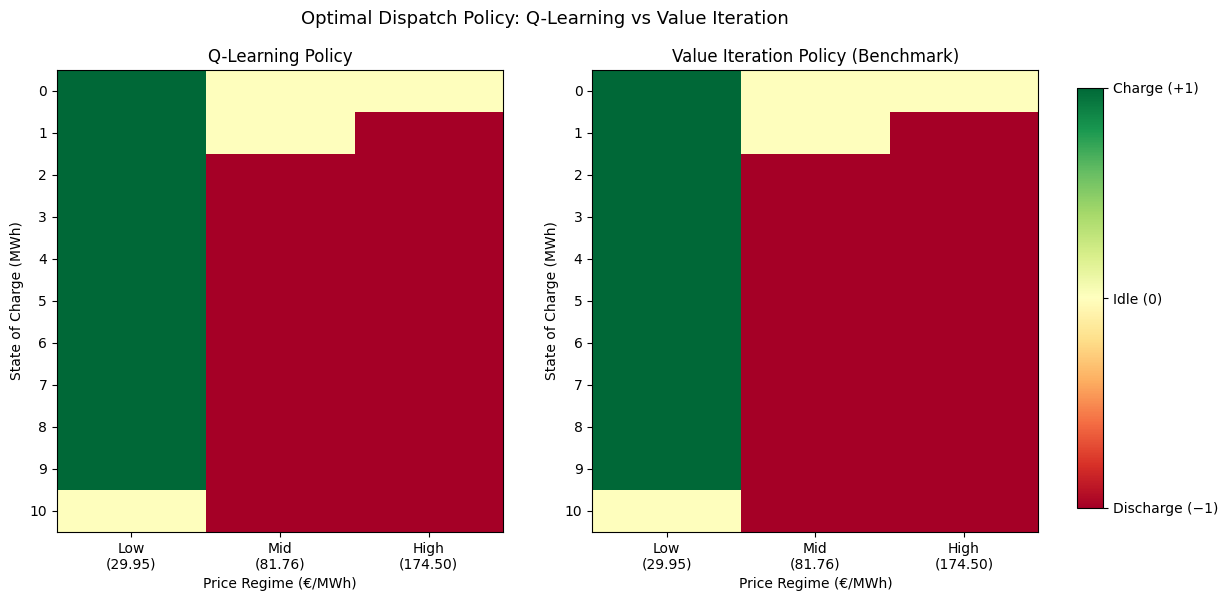

In [10]:
# ── Plot 2: Policy comparison heatmap (Q-Learning vs Value Iteration) ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, pol, title in zip(axes,
                           [policy_ql, policy_vi],
                           ['Q-Learning Policy', 'Value Iteration Policy (Benchmark)']):
    im = ax.imshow(pol, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Low\n(29.95)', 'Mid\n(81.76)', 'High\n(174.50)'])
    ax.set_yticks(range(N + 1))
    ax.set_yticklabels(range(N + 1))
    ax.set_xlabel('Price Regime (€/MWh)')
    ax.set_ylabel('State of Charge (MWh)')
    ax.set_title(title)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=[-1, 0, 1])
cbar.ax.set_yticklabels(['Discharge (−1)', 'Idle (0)', 'Charge (+1)'])

plt.suptitle('Optimal Dispatch Policy: Q-Learning vs Value Iteration', fontsize=13)
plt.savefig('policy_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Both policies exhibit the same three-region structure across the full state space: charge at Low prices, discharge at Mid and High prices, and idle only where physical constraints bind. The degradation cost $c_{deg} = 2$ €/MWh disciplines cycling behaviour — without it, the agent would trade at every step regardless of the price spread, which is economically unrealistic and physically damaging to the battery.

The thresholds are economically interpretable. Under **High prices** (174.50 €/MWh), both policies discharge for all $SoC \geq 1$ and idle at $SoC = 0$. The net revenue from discharging — 174.50 - 2 = 172.50 €/MWh — is so large that selling is optimal whenever physically possible, and idling at $SoC = 0$ simply reflects the feasibility constraint.

Under **Mid prices** (81.76 €/MWh), both policies discharge for $SoC \geq 2$ and idle at $SoC \in \{0, 1\}$. At $SoC = 1$, the continuation value of preserving the last unit of charge slightly exceeds the net discharge revenue of 79.76 €/MWh, because the battery would otherwise be left empty and unable to exploit a possible transition to High prices next period.

Under **Low prices** (29.95 €/MWh), both policies charge for all $SoC \leq 9$ and idle at $SoC = 10$. This reflects the buy-low logic of storage arbitrage: the net cost of charging (29.95 + 2 = 31.95 €/MWh) is far below the expected discharge revenue under Mid (79.76 €/MWh) or High (172.50 €/MWh) prices, so the agent accumulates energy across nearly the entire SoC range. At $SoC = 10$ the battery is physically full and cannot charge further, so the agent idles and waits for a price regime transition.

The per-state adaptive learning rate ($\alpha = 1/n^{0.6}$) is the key algorithmic improvement that produces this level of agreement. In the stylised model (Section 3), fixed $\alpha = 0.1$ and fixed $\varepsilon = 0.1$ created an exploration asymmetry: discharge yielded immediate positive reward and was updated frequently, while idle's value depended on delayed continuation signals that propagated slowly. The adaptive rate gives each state-action pair its own learning rate proportional to its visit frequency, ensuring that even rare pairs — such as Low price, high SoC — receive sufficiently large updates to converge to their true values.

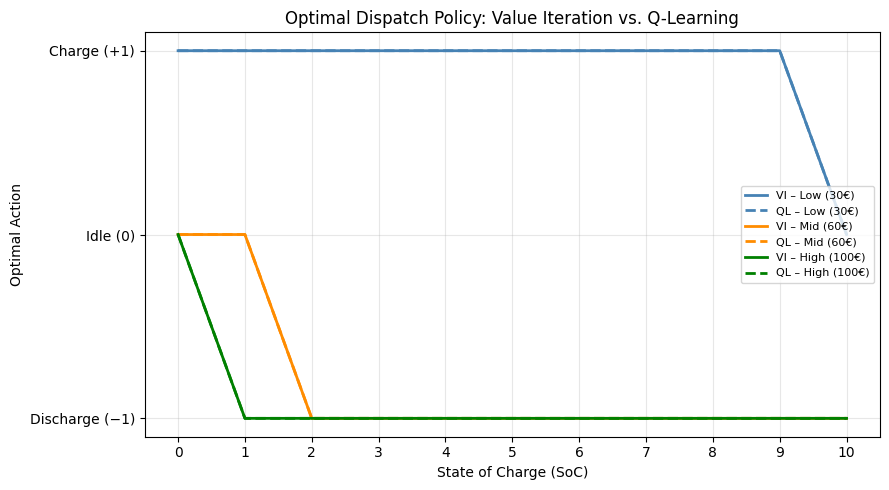

In [11]:
# ── Line chart: VI vs Q-Learning ─────────────────
price_labels = ['Low (30€)', 'Mid (60€)', 'High (100€)']
colors = ['steelblue', 'darkorange', 'green']
soc_range = np.arange(N+1)

fig, ax = plt.subplots(figsize=(9, 5))
for p in range(3):
    ax.plot(soc_range, policy_vi[:, p],
            color=colors[p], linewidth=2,
            label=f'VI – {price_labels[p]}')
    ax.plot(soc_range, policy_ql[:, p],
            color=colors[p], linewidth=2, linestyle='--',
            label=f'QL – {price_labels[p]}')

ax.set_xlabel('State of Charge (SoC)')
ax.set_ylabel('Optimal Action')
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Discharge (−1)', 'Idle (0)', 'Charge (+1)'])
ax.set_xticks(soc_range)
ax.legend(loc='center right', fontsize=8)
ax.set_title('Optimal Dispatch Policy: Value Iteration vs. Q-Learning')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('policy_comparison_line.png', dpi=150)
plt.show()

**Policy comparison: line chart view.**

The line chart confirms the heatmap result. Solid lines (VI) and dashed lines (QL) overlap completely across all three price regimes and all SoC levels. Q-learning reproduces the exact threshold structure of the Value Iteration benchmark, with a greedy evaluation gap of **0.0%**.


### 4.3 Simulated Dispatch Path



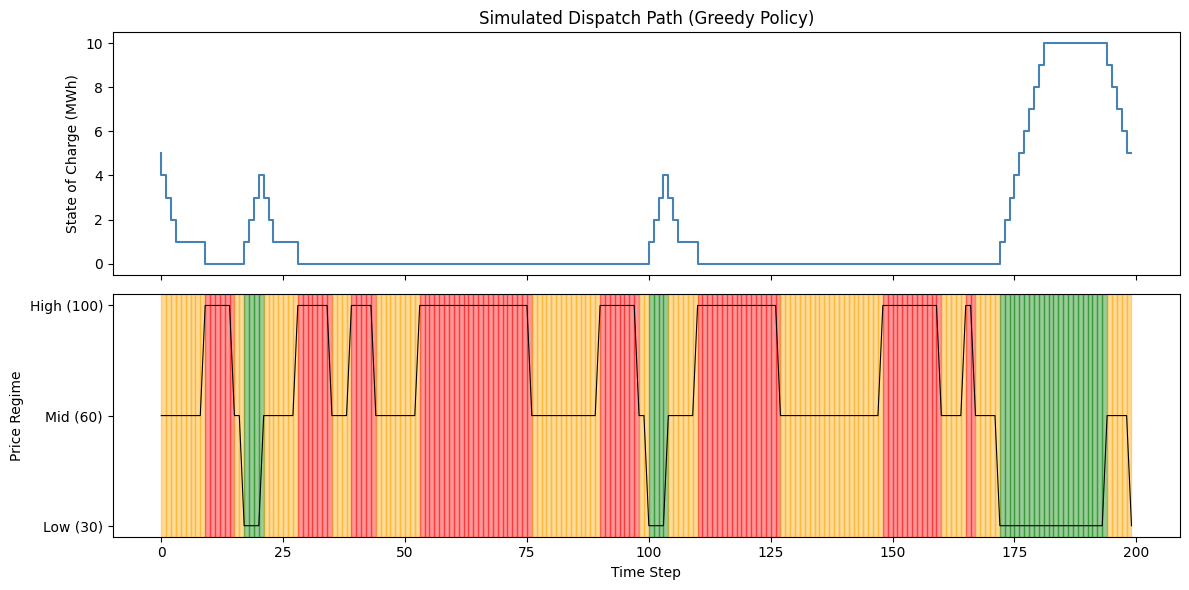

In [12]:
# ── Plot 3: Simulated dispatch path ─────────────
np.random.seed(0)
T = 200
soc_path = []
price_path = []
action_path = []

soc = 5
price_idx = 1  # start at Mid

for t in range(T):
    soc_path.append(soc)
    price_path.append(price_idx)

    valid = get_valid_actions(soc)
    valid_idx = [np.where(actions == a)[0][0] for a in valid]
    q_vals = [Q[soc, price_idx, i] for i in valid_idx]
    best_idx = valid_idx[np.argmax(q_vals)]
    action = actions[best_idx]
    action_path.append(action)

    soc, price_idx = get_next_state(soc, price_idx, action)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.step(range(T), soc_path, color='steelblue', linewidth=1.5)
ax1.set_ylabel('State of Charge (MWh)')
ax1.set_ylim(-0.5, N + 0.5)
ax1.set_title('Simulated Dispatch Path (Greedy Policy)')

price_labels = ['Low (30)', 'Mid (60)', 'High (100)']
colors = ['green', 'orange', 'red']
for t in range(T - 1):
    ax2.axvspan(t, t+1, color=colors[price_path[t]], alpha=0.4)
ax2.set_ylabel('Price Regime')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(price_labels)
ax2.plot(range(T), price_path, color='black', linewidth=0.8)
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.savefig('dispatch.png', dpi=150)
plt.show()

The simulated path confirms the core arbitrage logic: SoC rises during Low price periods (green background) as the agent charges, and falls during Mid and High periods (orange/red) as the agent discharges. This charge-low, discharge-high cycle repeats throughout the simulation, demonstrating that the learned policy captures the economic logic of battery arbitrage without ever observing the price transition matrix.

The shape of these cycles is driven by the high persistence in the EPEX transition matrix. With diagonal entries of 0.94 (Low), 0.86 (Mid), and 0.92 (High), the price process tends to remain in the same regime for extended stretches — on average roughly 16 steps for Low, 7 for Mid, and 12 for High. This produces the distinctive pattern visible in the chart: long, uninterrupted charging ramps during Low spells, followed by long discharge runs during Mid/High spells. In contrast, the stylised model (diagonal 0.6, expected duration 2.5 steps) would produce much shorter, more frequent cycles. The high persistence also means that regime transitions, when they occur, tend to be decisive — once prices leave Low, the agent typically discharges for many consecutive steps before the next Low spell arrives.

Two further features of the path are notable. First, the battery spends a substantial fraction of time at $SoC = 0$. Once the agent exhausts stored energy during Mid/High periods, it must idle until a Low price spell arrives to recharge. The high Mid→Mid and High→High persistence means these idle-at-zero stretches can last many consecutive steps — for example, the long flat segment between roughly steps 50–90, where the battery sits empty through an extended sequence of Mid and High prices. This structural idle time is the main reason the continuous greedy evaluation (10.16 €/MWh) is lower than the episodic training reward (~13 €/MWh): training episodes reset to $SoC = 5$ every 100 steps, bypassing these empty-battery periods entirely.

Second, the battery reaches full capacity ($SoC = 10$) only once in the 200-step window — during a long Low price spell around step 170. In most cycles, prices transition away from Low before the battery can fill completely: the agent begins charging from near-zero, accumulates a few MWh, and is interrupted by a Mid or High transition that triggers immediate discharge. The typical SoC peak in most cycles is around 3–4 MWh rather than 10.


## 5. Summary

| | Stylised model | Real data (this notebook) |
|--|--|--|
| Price levels | 30 / 60 / 100 €/MWh | 29.95 / 81.76 / 174.50 €/MWh |
| Transition matrix diagonal | 0.6 / 0.6 / 0.6 | 0.94 / 0.86 / 0.92 |
| Exploration | Fixed ε = 0.1 | Decay 0.5 → 0.05 |
| Learning rate | Fixed α = 0.1 | Per-state 1/n^0.6 |
| Q-Learning gap vs VI | 1.1% | **0.0%** |

Calibrating the model to real EPEX Spot day-ahead prices (2020-2024) introduced two challenges absent from the stylised setting: a much wider price spread (174.50 vs 29.95 €/MWh, compared with 100 vs 30) and strong price persistence (diagonal entries 0.86-0.94, compared with 0.6). The wider spread amplifies the reward difference between correct and incorrect actions, while the high persistence creates unequal state coverage — some state-action pairs are visited orders of magnitude less frequently than others during training.

The per-state adaptive learning rate ($\alpha = 1/n^{0.6}$) is the key algorithmic improvement. By giving each state-action pair its own learning rate inversely proportional to visit frequency, the algorithm ensures that rarely visited pairs — such as boundary states under Low prices — receive sufficiently large updates to converge. Combined with ε-decay (0.5 → 0.05), this eliminates the exploration asymmetry that caused the 1.1% gap in the stylised model, producing an identical policy to Value Iteration with a gap of 0.0%.

The continuous greedy evaluation confirms that the learned policy captures the full arbitrage value available in the EPEX price process: 10.16 €/MWh per step, matching the Value Iteration benchmark exactly.

**Limitations and extensions.** The model remains stylised in several respects that would need to be addressed for real-world deployment. The three-state price discretisation loses intraday seasonality and price spikes; replacing it with a continuous AR(1) or regime-switching process calibrated to hourly EPEX data would better capture real price dynamics, but would require moving from tabular Q-learning to function approximation (e.g. DQN or semi-gradient SARSA). Similarly, the discrete SoC and ±1 MWh action space could be extended to continuous values, allowing partial charge/discharge decisions that reflect real battery operation. Finally, the current model assumes a stationary price process, whereas real electricity prices exhibit structural shifts driven by renewable capacity additions, policy changes, and seasonal demand patterns — an online learning approach that adapts to non-stationarity would be a natural next step.